# <span style="color:red"> DATASCI 151 - Practice Quiz #4 </span>

<font size = "4" >
This quiz is open book 

<br>

- You <span style="color:red"> CAN </span> use all material from the course repo

- You should <span style="color:red"> NOT </span> use other resources outside the course repo.

- You should <span style="color:red"> NOT </span> collaborate with other students

- Use of LLMs or any AI tools is <span style="color:red"> NOT ALLOWED </span>

- To get full credit, the code should work as intended. But try to attempt every problem - you can still receive partial credit.

<br>

Print the following string:

"I will abide by Emory's code of conduct"

In [44]:
print()

<font size = "4">

Import the libraries `numpy`, `matplotlib.pyplot`, and `pandas`. You probably want to give them aliases (nicknames) but it's not required.

In [45]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<font size = "4">

**Q1** Random Assignment

<font size = "3">

- Read in the dataset named "fifa23_players_basic.csv", assigning it to a DataFrame object. Each row of the dataset corresponds to a professional soccer (football) player.

- Use some method to randomly assign each player into two groups: "A" and "B". Each group should be assigned with equal probability (50% chance of being placed in either group). You can use any appropriate method to perform the random assignment.

- Add a new column to the DataFrame with the name "Group", where each entry is either the string "A" or "B".

In [46]:
# your code here

df = pd.read_csv("quiz_data/fifa23_players_basic.csv")

groups = []
for i in range(len(df)):
    assignment = np.random.random()
    if assignment >= 0.5:
        groups.append("A")
    else:
        groups.append("B")

df["Group"] = groups
print(df)

             Known As           Full Name  Overall  Potential  Value(in Euro)  \
0            L. Messi        Lionel Messi       91         91        54000000   
1          K. Benzema       Karim Benzema       91         91        64000000   
2      R. Lewandowski  Robert Lewandowski       91         91        84000000   
3        K. De Bruyne     Kevin De Bruyne       91         91       107500000   
4           K. Mbappé       Kylian Mbappé       91         95       190500000   
...               ...                 ...      ...        ...             ...   
18534      D. Collins      Darren Collins       47         56          110000   
18535    Yang Dejiang        Dejiang Yang       47         57           90000   
18536       L. Mullan         Liam Mullan       47         67          130000   
18537    D. McCallion    Daithí McCallion       47         61          100000   
18538        N. Rabha         Nabin Rabha       47         50           60000   

      Positions Played Best

<font size = "4">

**Q2** Plotting two groups

<font size = "3">

- Continue to use the DataFrame you created in Q1

- Use `.query` to extract all players in Group "A", assigning it to a new DataFrame called `groupA`

- Use `.query` to extract all players in Group "B", assigning it to a new DataFrame called `groupB`

- Use ``matplotlib.pyplot.subplots`` to create two side by side scatter plots (1 row, 2 columns)

- In the left figure, plot the columns ``Age`` vs. ``Overall`` for the data in ``groupA`` (so the horizontal axis will correspond to "Age")
- In the right figure, plot the columns ``Age`` vs. ``Overall`` for the data in ``groupB`` (so the horizontal axis will correspond to "Age")
- Label the axes for both plots. Create a title for **both** plots, indicating whether Group A or Group B is shown.

**Note**: If the assignment into groups was done randomly, then we expect that the scatter plots will be **very similar**

**Hint**: ``matplotlib.pyplot.subplots`` was used in the Lecture 09 notebook on Random Variables. Solve the problem using two executions of `matplotlib.pyplot.scatter` first, then review how to use subplots.

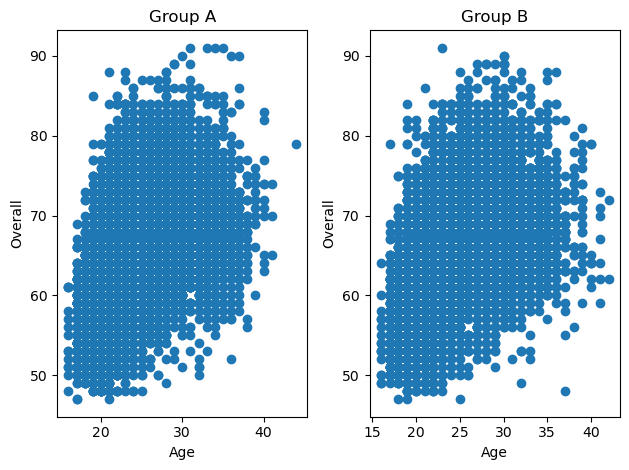

In [47]:
# your code here

groupA = df.query("Group == 'A'")
groupB = df.query("Group == 'B'")

fig, axes = plt.subplots(1, 2)

axes[0].scatter(groupA["Age"], groupA["Overall"])
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Overall")
axes[0].set_title("Group A")

axes[1].scatter(groupB["Age"], groupB["Overall"])
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Overall")
axes[1].set_title("Group B")

plt.tight_layout()
plt.show()


<font size = "4">

**Q3** Merging DataFrames

<font size = "3">

In the code cell below, a Pandas DataFrame is created manually based on the [four statistical regions defined by the U.S. Census Bureau](https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States). It allows us to determine which region a given state belongs to (including Washington D.C.)

In [48]:
import pandas as pd

state_lst = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "District of Columbia", "Florida",
    "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"
]

region_lst = [
    "South", "West", "West", "South", "West",
    "West", "Northeast", "South", "South", "South",
    "South", "West", "West", "Midwest", "Midwest", "Midwest",
    "Midwest", "South", "South", "Northeast", "South",
    "Northeast", "Midwest", "Midwest", "South", "Midwest",
    "West", "Midwest", "West", "Northeast", "Northeast",
    "West", "Northeast", "South", "Midwest", "Midwest",
    "South", "West", "Northeast", "Northeast", "South",
    "Midwest", "South", "South", "West", "Northeast",
    "South", "West", "South", "Midwest", "West"
]

df_region = pd.DataFrame({"state": state_lst, "region":region_lst})

df_region.head()

,state,region
0,Alabama,South
1,Alaska,West
2,Arizona,West
3,Arkansas,South
4,California,West


<font size = "4">

- Read in the file "president_county_candidate.csv" from the quiz_data folder, assigning it to a Pandas DataFrame.

- This dataset contains information about the total number of votes won by candidates during the 2020 U.S. presidential election on a county-by-county basis.

- Merge this DataFrame with `df_region` defined above. Perform the merge so that the columns are in the following order: "region", "state", "county", "candidate", "total_votes"

In [49]:
# your code here

df2 = pd.read_csv("quiz_data/president_county_candidate.csv")
df_merged = pd.merge(left=df_region, right=df2, on="state")

df_merged = df_merged[["region", "state", "county", "candidate", "total_votes"]]
df_merged

,region,state,county,candidate,total_votes
0,South,Alabama,Cherokee County,Donald Trump,10583
1,South,Alabama,Cherokee County,Joe Biden,1624
2,South,Alabama,Cherokee County,Jo Jorgensen,82
3,South,Alabama,Cherokee County,Write-ins,12
4,South,Alabama,Chilton County,Donald Trump,16085
...,...,...,...,...,...
32172,West,Wyoming,Weston County,Donald Trump,3107
32173,West,Wyoming,Weston County,Joe Biden,360
32174,West,Wyoming,Weston County,Jo Jorgensen,46
32175,West,Wyoming,Weston County,Brock Pierce,20


<font size = "4">

**Q4** Counting votes in a region

<font size = "3">

- For this question, use the merged DataFrame you created above.

- Use the `.query()` and `.sum()` methods to calculate how many total votes Gloria La Riva won in states belonging to the "West" region of the United States. Print this value (an integer) to the screen 

- Then try to compute the answer to the same question in a single line of code using "chaining".

In [ ]:
# your code here

west_gloria = df_merged.query("region == 'West' and candidate == 'Gloria La Riva'")

total_votes_gloria = west_gloria['total_votes'].sum()

print(int(total_votes_gloria))

print(int(df_merged.query("region == 'West' and candidate == 'Gloria La Riva'")['total_votes'].sum()))


59690
59690


<font size = "4">


**Q5** Computing average votes for different regions

<font size = "3">

- For this question, continue to use the merged DataFrame you created in question 3.

- Use `.query` to extract the subset of the data corresponding to the candidate "Howie Hawkins".

- Use the `.groupby` method to calculate the average number of votes Howie Hawkins won in Midwest states, Northeast states, South states, and West states, respectively.

In [51]:
# your code here

howie_averages = df_merged.query("candidate == 'Howie Hawkins'").groupby("region")['total_votes'].mean()

print(howie_averages)

region
Midwest      156.970435
Northeast     61.351893
South        121.760198
West         507.346008
Name: total_votes, dtype: float64


<font size = "4">

**Q6** Recoding categorical variables

<font size = "3">

- Read in the familiar dataset `features.csv` from the quiz_data folder, assigning it to a DataFrame.

- Recode the "mpg" variable into a categorial variable with the values

    - "Low mileage" if $\textrm{mpg} \leq 20$
    - "Medium mileage" if $20 < \textrm{mpg} \leq 34$
    - "High mileage" if $34 < \textrm{mpg}$

- Do this in two different ways

    1. Using the `.apply` method.

    2. Using the function `pandas.cut`

In [ ]:
# your code here
df = pd.read_csv("quiz_data/features.csv")

def recode_mpg(val):
    if val <= 20:
        return "Low mileage"
    elif val <= 34:
        return "Medium mileage"
    else:
        return "High mileage"

df['mpg_category_apply'] = df['mpg'].apply(recode_mpg)

print(df)

bins = [-float('inf'), 20, 34, float('inf')]
labels = ["Low mileage", "Medium mileage", "High mileage"]

df['mpg_category_cut'] = pd.cut(df['mpg'], bins=bins, labels=labels)


      mpg  cylinders  displacement horsepower  weight  acceleration  \
0    18.0          8           307        130    3504          12.0   
1    15.0          8           350        165    3693          11.5   
2    18.0          8           318        150    3436          11.0   
3    16.0          8           304        150    3433          12.0   
4    17.0          8           302        140    3449          10.5   
..    ...        ...           ...        ...     ...           ...   
393  27.0          4           140         86    2790          15.6   
394  44.0          4            97         52    2130          24.6   
395  32.0          4           135         84    2295          11.6   
396  28.0          4           120         79    2625          18.6   
397  31.0          4           119         82    2720          19.4   

    vehicle id mpg_category_apply  
0    C-1689780        Low mileage  
1    B-1689791        Low mileage  
2    P-1689802        Low mileage  
3  